# CNN Classification on MNIST (Beginner Tutorial)

This notebook is a full image-classification tutorial from data inspection to CNN evaluation.

Learning goals: by the end, you should be able to preprocess image tensors correctly, compare linear baseline vs CNN, and interpret class-level errors with confusion-matrix evidence.

Use the same workflow in every section: read the concept first, predict what you expect, run the code, and then explain what the output means in plain language.


## 1. Imports + Reproducibility Seed

This section initializes image-modeling tools and seed control.

How to read this step: output is often minimal; success means imports complete and seed setup executes before any split/training operation.

If this fails, resolve environment setup before interpreting any model behavior.

Go deeper: [TensorFlow/Keras built-in training methods](https://www.tensorflow.org/guide/keras/training_with_built_in_methods).


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset

Now you load MNIST and verify tensor schema.

How to read printed output:
- `Train full: (N, 28, 28) (N,)` means image and label counts align.
- `Test: (M, 28, 28) (M,)` confirms held-out evaluation size.

Contextual interpretation: this confirms grayscale 28x28 images with integer labels. Later preprocessing should preserve this count integrity while changing scale and shape format.

Go deeper: [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data).


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Train full:', X_train_full.shape, y_train_full.shape)
print('Test:', X_test.shape, y_test.shape)


Train full: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


## 3. Data Quality Check

This section inspects value range, missing entries, and class distribution.

How to read printed output:
- Pixel range should usually be `0..255` before normalization.
- Missing counts should be zero for this dataset.
- Class-count bar plot reveals whether imbalance may affect class-level precision/recall.

Interpretation rule: fix data-range/quality issues now, because model comparisons are meaningless if inputs are inconsistent.

Go deeper: [Common pitfalls in scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).


Pixel range: 0 to 255
Missing pixels in train: 0
Missing labels in train: 0


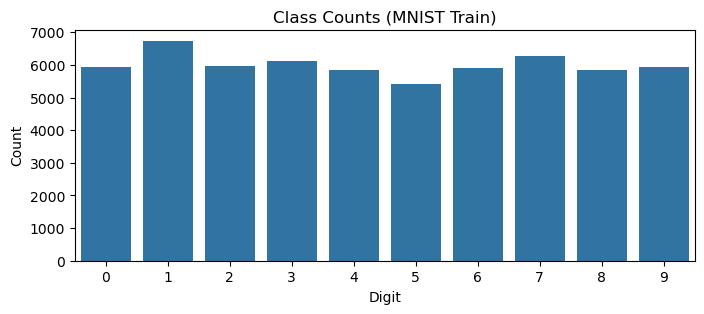

In [3]:
print('Pixel range:', X_train_full.min(), 'to', X_train_full.max())
print('Missing pixels in train:', np.isnan(X_train_full).sum())
print('Missing labels in train:', np.isnan(y_train_full).sum())

class_counts = pd.Series(y_train_full).value_counts().sort_index()
plt.figure(figsize=(8, 3))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Counts (MNIST Train)')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()


## 4. EDA (PCA + t-SNE)

This section builds intuition via sample digits plus PCA/t-SNE projections of flattened images.

How to read printed output and plots:
- Named PCA print (`PC1`, `PC2`, cumulative) tells you how much linear variance is retained in 2D.
- If, for example, `PC1=0.10` and `PC2=0.07`, cumulative variance is `0.17` (17%).
- Lower cumulative variance is common in high-dimensional image data and does **not** mean PCA failed; it means 2 components cannot capture all image variation.
- t-SNE emphasizes local neighborhoods and potential cluster overlap.
- Overlap regions often foreshadow confusion-matrix substitutions.

How to read PCA composition output for images: the notebook prints top contributing pixel coordinates for each component and also visualizes PC loading maps. Higher absolute loading means that pixel contributes more strongly to that component; sign shows direction (positive vs negative contribution on that axis).

Contextual interpretation: PCA/t-SNE are exploratory tools to generate hypotheses about difficult classes; final validation comes from classification metrics and confusion analysis.

Go deeper on dimensionality reduction and interpretation: [scikit-learn PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [How to Use t-SNE Effectively (Distill)](https://distill.pub/2016/misread-tsne/), and [van der Maaten & Hinton (2008)](https://www.jmlr.org/papers/v9/vandermaaten08a.html).


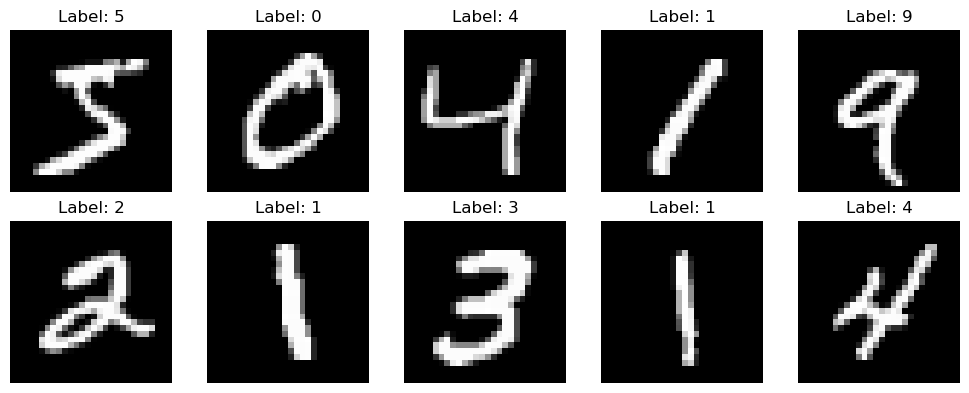

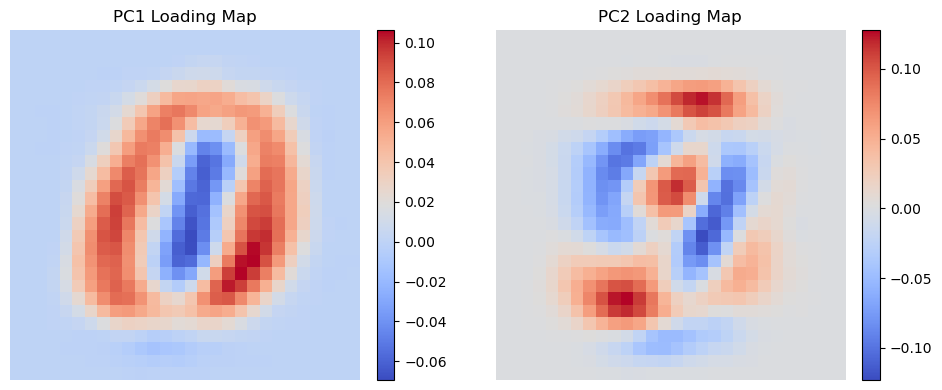

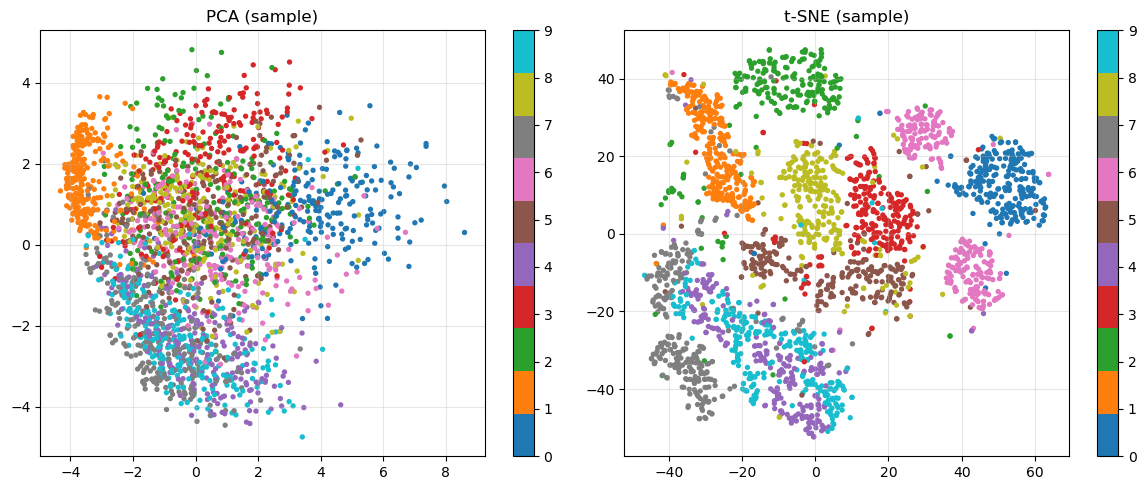

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_full[i], cmap='gray')
    ax.set_title(f'Label: {y_train_full[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

flat = X_train_full.reshape(len(X_train_full), -1) / 255.0

sample_n = 2500
idx = np.random.choice(len(flat), size=sample_n, replace=False)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(flat[idx])

# Visualize component loadings as 28x28 maps for intuition.
pc1_map = pca.components_[0].reshape(28, 28)
pc2_map = pca.components_[1].reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(pc1_map, cmap='coolwarm')
axes[0].set_title('PC1 Loading Map')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pc2_map, cmap='coolwarm')
axes[1].set_title('PC2 Loading Map')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

X_tsne = TSNE(n_components=2, perplexity=30, max_iter=900, random_state=SEED).fit_transform(flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_full[idx], s=8, cmap='tab10')
axes[0].set_title('PCA (sample)')
axes[0].grid(alpha=0.3)
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train_full[idx], s=8, cmap='tab10')
axes[1].set_title('t-SNE (sample)')
axes[1].grid(alpha=0.3)
plt.colorbar(sc1, ax=axes[1])

plt.tight_layout()
plt.show()


## 5. Preprocessing

This section prepares aligned arrays for split and training.

How to read printed output: `Prepared train arrays` should show matching sample counts for inputs and labels. Alignment problems here will quietly poison every downstream metric.

Treat this as a pipeline-integrity checkpoint before normalization and channel expansion.


In [5]:
X_all = X_train_full.astype('float32')
y_all = y_train_full.copy()

print('Prepared train arrays:', X_all.shape, y_all.shape)


Prepared train arrays: (60000, 28, 28) (60000,)


## 6. Train/Val/Test Split

This section performs split, normalization, and channel-axis expansion.

How to read printed output:
- Shapes should be `(n, 28, 28, 1)` after channel expansion.
- The last dimension `1` indicates grayscale channel format expected by Conv2D.
- Train/val/test sample counts should align with corresponding labels.

Contextual interpretation: shape correctness is a hard requirement for CNN behavior; if shapes are wrong, architecture quality is irrelevant.

Go deeper on leakage-safe splitting and scaling: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [data leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage), and [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_all,
)

# Normalize to [0,1] and add channel axis for CNN.
X_train = (X_train / 255.0)[..., np.newaxis]
X_val = (X_val / 255.0)[..., np.newaxis]
X_test_nn = (X_test.astype('float32') / 255.0)[..., np.newaxis]

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test_nn.shape)


Train: (48000, 28, 28, 1) Val: (12000, 28, 28, 1) Test: (10000, 28, 28, 1)


## 7. Baseline Model

This section fits logistic regression on flattened pixels as baseline.

How to read `classification_report`: use the same interpretation as in Iris (`precision`, `recall`, `f1-score`, `support`), but pay extra attention to class-level variability because some digits are visually more confusable.

Contextual interpretation: this baseline quantifies what is possible without learned spatial filters, so CNN improvements should be measured against it explicitly.

Go deeper: [LogisticRegression API](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).


In [7]:
subset = 12000
Xb = X_train.reshape(len(X_train), -1)[:subset]
yb = y_train[:subset]
Xb_test = X_test_nn.reshape(len(X_test_nn), -1)

baseline = LogisticRegression(max_iter=200, solver='lbfgs', random_state=SEED)
baseline.fit(Xb, yb)
baseline_pred = baseline.predict(Xb_test)

print('Baseline (Logistic Regression) report:\n')
print(classification_report(y_test, baseline_pred))


Baseline (Logistic Regression) report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       980
           1       0.95      0.98      0.96      1135
           2       0.91      0.87      0.89      1032
           3       0.88      0.90      0.89      1010
           4       0.92      0.91      0.91       982
           5       0.87      0.85      0.86       892
           6       0.93      0.94      0.94       958
           7       0.92      0.92      0.92      1028
           8       0.88      0.84      0.86       974
           9       0.89      0.90      0.90      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 8. Neural Network Model

Now you train a compact CNN with early stopping.

How to read this step: printed text may be limited, so the main interpretation will come from section 9 curves and section 10 final metrics. Focus on stable validation behavior and baseline improvement.

If train improves but validation plateaus/falls, expect overfitting signals in the next section.

Go deeper on model construction and stopping criteria: [Keras Sequential guide](https://keras.io/guides/sequential_model/) and [EarlyStopping](https://keras.io/api/callbacks/early_stopping/).


In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(16, 3, activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=128,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8635 - loss: 0.4522 - val_accuracy: 0.9599 - val_loss: 0.1289
Epoch 2/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9593 - loss: 0.1385 - val_accuracy: 0.9739 - val_loss: 0.0817
Epoch 3/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9691 - loss: 0.1012 - val_accuracy: 0.9782 - val_loss: 0.0719
Epoch 4/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9751 - loss: 0.0833 - val_accuracy: 0.9843 - val_loss: 0.0547
Epoch 5/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9784 - loss: 0.0710 - val_accuracy: 0.9822 - val_loss: 0.0612
Epoch 6/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9802 - loss: 0.0642 - val_accuracy: 0.9847 - val_loss: 0.0551
Epoch 7/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9823 - loss: 0.0571 - val_accuracy: 0.9862 - val_loss: 0.0510
Epoch 8/128
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9841 - loss: 0.0527 - val_accu

## 9. Training Curves

This section visualizes learning dynamics.

How to read the plots: evaluate trend direction and train-validation gap over epochs. Healthy learning usually shows improving validation metrics with controlled divergence from training curves.

Use curve behavior to justify tuning choices, rather than tuning blindly.


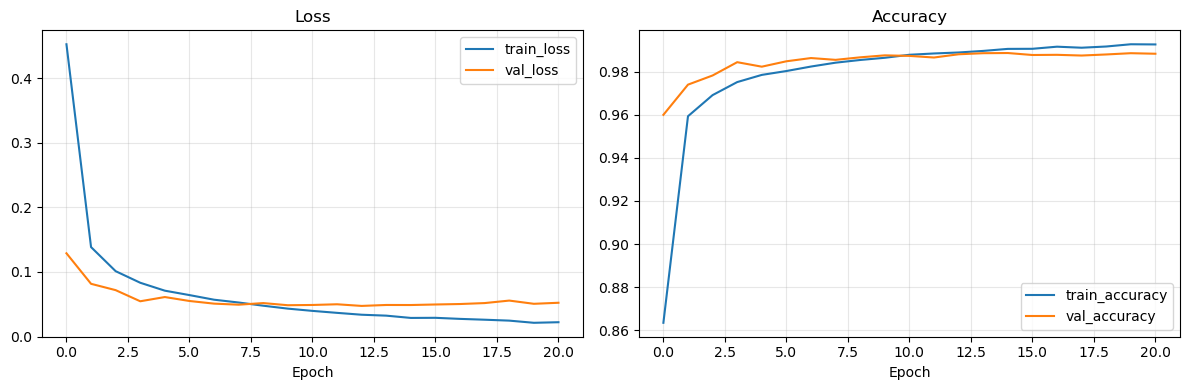

In [9]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['loss'], label='train_loss')
axes[0].plot(history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['accuracy'], label='train_accuracy')
axes[1].plot(history_df['val_accuracy'], label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Final Evaluation

This section reports final CNN performance via classification report and confusion matrix.

How to read printed output (`CNN report`): inspect per-class precision/recall/F1 and compare against baseline to identify where CNN brings the most benefit.

How to read confusion matrix: off-diagonal counts are specific substitution pathways. Connect those to overlap cues seen in EDA for a complete interpretation loop.

Go deeper: [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) and [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html).


CNN report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



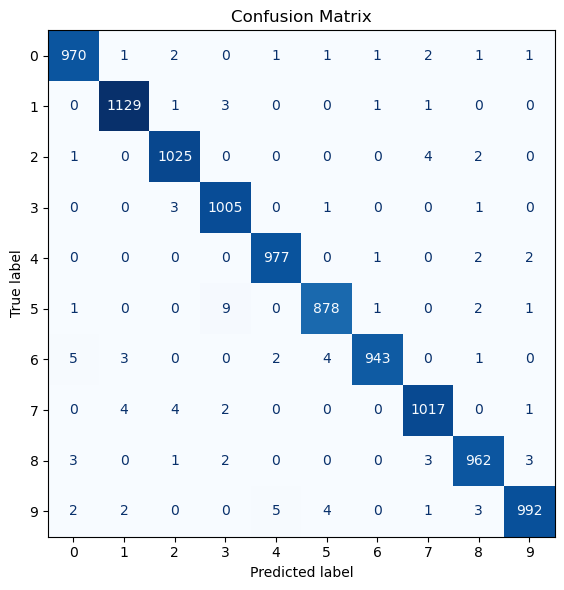

In [10]:
pred = model.predict(X_test_nn, verbose=0).argmax(axis=1)

print('CNN report:\n')
print(classification_report(y_test, pred))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=[str(i) for i in range(10)],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. Mini Exercises

Use this section as a structured experiment log. Predict the effect first, run the experiment, then explain the output with direct metric and curve evidence.


1. Reduce training subset to 50% and explain the resulting accuracy change.
2. Increase first Conv2D filters (`16 -> 32`) and discuss runtime versus quality gain.
3. Disable early stopping and describe overfitting signatures in the curves.
4. Compare t-SNE sample sizes (`1000` vs `3000`) and explain runtime/visual-stability tradeoffs.

For broader study, keep the [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) and [TensorFlow/Keras guides](https://www.tensorflow.org/guide/keras) open while experimenting.
